# 05 · Segmentation, baseline and quality control

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Build event-locked epochs from continuous EEG, audit discarded trials and preserve run identity.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

A classifier reports excellent accuracy, but many more trials were discarded from one class than the other. We trace each trial from its event marker through epoch boundaries, baseline correction and quality control before trusting its label.

### By the end you should be able to

- Convert an event sample and time interval into epoch boundaries.
- Explain the difference between baseline correction and high-pass filtering.
- Audit dropped trials by class and run.
- Recognize overlap and artifact rejection as possible sources of evaluation bias.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

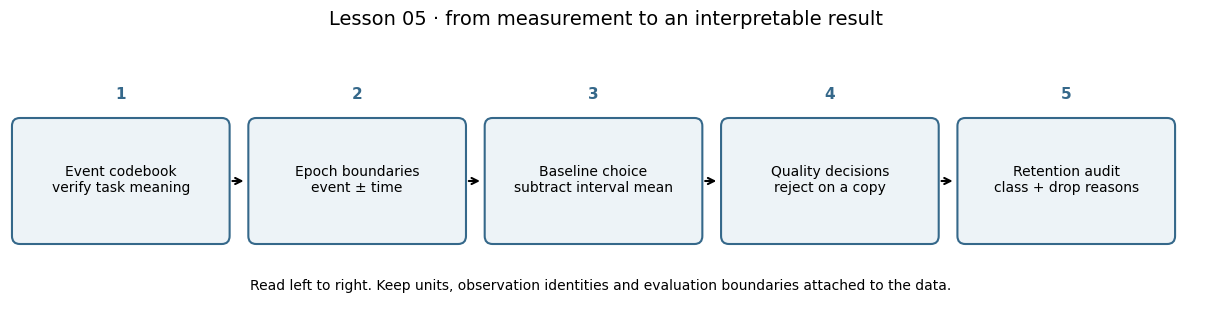

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Event codebook\nverify task meaning', 'Epoch boundaries\nevent ± time', 'Baseline choice\nsubtract interval mean', 'Quality decisions\nreject on a copy', 'Retention audit\nclass + drop reasons']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 05 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Event codebook: verify task meaning → Epoch boundaries: event ± time → Baseline choice: subtract interval mean → Quality decisions: reject on a copy → Retention audit: class + drop reasons.

## Symbols and a calculation by hand

$s_0$: event sample; $[a,b]$: relative epoch interval; $B$: baseline sample mask; $q$: peak-to-peak threshold.

### Derive the operation before calling the library

Epoch sample indices are approximately $s_0+\operatorname{round}(af_s)$ through $s_0+\operatorname{round}(bf_s)$, inclusive. At 100 Hz around sample 1000, $[-0.2,0.8]$ maps to 980 through 1080, giving 101 samples.

Baseline subtraction is $x'(t)=x(t)-\bar x_B$. For $x=[5,7,9,8,6]$ and baseline first two samples, $\bar x_B=6$ and $x'=[-1,1,3,2,0]$. The original and corrected peak-to-peak ranges are both 4 because $(\max x-b)-(\min x-b)=\max x-\min x$. Baseline correction cannot rescue a trial from a peak-to-peak criterion merely by changing its offset.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Events are the link between measurement and task

An event array has three columns: sample index, previous event value and event code. The code is a lookup key, not a physiological measurement. Its interpretation comes from the dataset protocol. The same annotation name can mean different tasks in different runs; this is why the motor-imagery notebooks select documented run numbers explicitly.

For sampling rate $f_s$ and event sample $s_0$, relative time $t$ maps approximately to $s_0+\operatorname{round}(t f_s)$. MNE also tracks `first_samp`, which matters after cropping or when a file starts at a nonzero acquisition sample. Do not assume that an array position is always an absolute event index. Inspect `raw.first_samp`, the event samples and `epochs.times` together.

### What one epoch contains

An epoch is a short multichannel segment aligned to a scientifically meaningful event. Negative times are before that event; positive times are after it. The interval should follow the hypothesis. A P300 response occurs hundreds of milliseconds after a flash, while imagery rhythm changes can extend over seconds. A broad interval increases available context but also increases overlap, artifacts and computational cost.

With both endpoints included, an interval from $a$ to $b$ has approximately

$$T=\operatorname{round}((b-a)f_s)+1$$

samples when the endpoints lie on the sample grid. The actual `epochs.times` array is the authority. A request that extends beyond the recording cannot be satisfied by inventing data; MNE records why such an epoch was dropped.

### Baseline subtraction and rejection

Baseline correction subtracts the mean of a selected pre-event interval from every time point of each channel and trial:

$$x'_{nct}=x_{nct}-\frac{1}{|B|}\sum_{u\in B}x_{ncu}.$$

It aligns an offset but does not remove arbitrary drift. The baseline must be relevant to the comparison; a preceding task response can make a supposedly neutral baseline unequal between conditions. Baseline subtraction also introduces dependence between all samples and the baseline estimate.

Peak-to-peak rejection checks $\max_t x_{nct}-\min_t x_{nct}$ against a threshold for each channel. It is sensitive to large excursions but cannot detect every artifact. The threshold is in volts for EEG: confusing volts with microvolts can reject everything or nothing. Our real-data demonstration uses a deliberately explicit threshold and prints retained class counts so the consequence is visible. It is an illustration, not a universal recommended value.

Keep the unmodified epoch collection, the selection indices and the drop log. If rejection differs strongly by class or run, ask whether the task itself caused movement or whether the sensor quality changed over time. More data cleaning can make the surviving sample less representative of future use.

## Visual intuition · Draw epoch boundaries on a continuous recording

**Try it:** Find the pre-event baseline and the post-event interval. Which samples are shared by neighboring epochs?

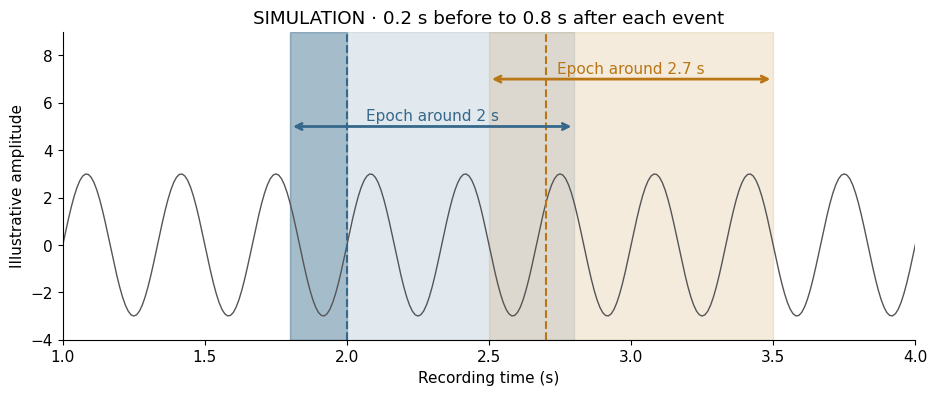

In [3]:
vis_t=np.arange(600)/100
vis_trace=np.sin(2*np.pi*3*vis_t)*3
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(vis_t,vis_trace,color='#555',lw=1)
for event_time,color,ypos in [(2.,'#35688a',5),(2.7,'#b87714',7)]:
    ax.axvspan(event_time-.2,event_time+.8,color=color,alpha=.14)
    ax.axvline(event_time,color=color,linestyle='--')
    ax.annotate('',xy=(event_time+.8,ypos),xytext=(event_time-.2,ypos),arrowprops=dict(arrowstyle='<->',color=color,lw=2))
    ax.text(event_time+.3,ypos+.25,f'Epoch around {event_time:g} s',ha='center',color=color)
ax.axvspan(1.8,2.,color='#35688a',alpha=.35)
ax.set(xlim=(1,4),ylim=(-4,9),xlabel='Recording time (s)',ylabel='Illustrative amplitude',title='SIMULATION · 0.2 s before to 0.8 s after each event')
plt.show()

### Worked interpretation

The first epoch ends at 2.8 s; the second starts at 2.5 s. Their overlap is 0.3 s. A random split of these windows would share raw samples across partitions. The darker pre-event segment illustrates a baseline, not an automatic indication of rest.

## Guided practice 1 · sample boundaries

Calculate a segment around an event at sample 1000, with 100 Hz sampling and limits −0.2 to 0.8 s. Predict the number of samples before evaluating.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_event=1000;demo_fs=100
demo_start=demo_event+round(-.2*demo_fs)
demo_stop=demo_event+round(.8*demo_fs)
demo_indices=np.arange(demo_start,demo_stop+1)
print(demo_start,demo_stop,len(demo_indices))
assert len(demo_indices)==101

980 1080 101


### Why this result makes sense

Python slices normally exclude their stop index; MNE epoch time bounds include the final sample when available. This is a common one-sample discrepancy.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · baseline subtraction

Use an offset trace and a two-sample baseline. Compare the response relative to zero before and after correction.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_trace=np.array([5.,7.,9.,8.,6.])
demo_corrected=demo_trace-demo_trace[:2].mean()
print('Corrected:',demo_corrected)
assert np.isclose(demo_corrected[:2].mean(),0)
assert np.isclose(np.ptp(demo_trace),np.ptp(demo_corrected))

Corrected: [-1.  1.  3.  2.  0.]


### Why this result makes sense

Subtracting a constant changes the offset but not peak-to-peak range. Baseline correction and amplitude rejection therefore answer different questions.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · unequal rejection

Create a small audit table. Calculate retention within each class, rather than only the total number of surviving epochs.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_audit=pd.DataFrame({'class':['left']*5+['right']*5,'keep':[1,1,1,1,1,1,0,0,1,0]})
print(demo_audit.groupby('class')['keep'].agg(['sum','count','mean']))

       sum  count  mean
class                  
left     5      5   1.0
right    2      5   0.4


### Why this result makes sense

The retained data have a different class composition from the original data. Report per-class retention with the modeling results.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · overlapping windows

Two windows can share raw samples even when they have different row indices. Compute their intersection.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_window_a=set(range(0,200))
demo_window_b=set(range(100,300))
print('Shared samples:',len(demo_window_a & demo_window_b))
print('Fraction of each window shared:',len(demo_window_a & demo_window_b)/200)

Shared samples: 100
Fraction of each window shared: 0.5


### Why this result makes sense

Randomly splitting these windows leaks part of the same recording into both sets. Use blocks or runs and, where necessary, a gap between partitions.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Baseline function

Implement baseline_center for a trial × channel × time array and a Boolean time mask.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def baseline_center(values, mask):
    # TODO: subtract one baseline mean per trial and channel.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def baseline_center(values,mask):
    return values-values[...,mask].mean(axis=-1,keepdims=True)

In [10]:
demo_cube=np.arange(24.).reshape(2,3,4)
demo_mask=np.array([True,True,False,False])
answer=baseline_center(demo_cube,demo_mask)
if answer is not None:
    assert answer.shape==demo_cube.shape
    assert np.allclose(answer[...,demo_mask].mean(axis=-1),0)
    assert np.allclose(answer[...,3]-answer[...,2],1)
    print('Baseline checks passed.')
else: print('Exercise pending: implement baseline_center.')

Baseline checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A cue at sample $s_i$ becomes an epoch $X_i[:,n]=x[:,s_i+n]$ over a specified interval. Event latency is part of the measurement: stimulus display delay and clock drift cannot be corrected by classification. MNE accounts for `raw.first_samp`; do not subtract it twice.

Baseline correction is $X_i'(c,t)=X_i(c,t)-|B|^{-1}\sum_{u\in B}X_i(c,u)$. It assumes the reference interval is appropriate and can propagate baseline noise across the full trial. Motor imagery decoding often uses bandpassed post-cue power without ERP baseline subtraction. Peak-to-peak rejection removes an epoch when $\max_t X_i(c,t)-\min_t X_i(c,t)>\theta_c$.

Rejection changes the analyzed population. Report counts before and after, by class and run, and separate boundary drops from amplitude drops. Overlapping sliding windows from one trial must remain in one split group. Preserve subject, session, run and original trial identifiers before any concatenation.

## Parse annotations explicitly
The T1/T2 mapping depends on the run. Run 4 is imagined left/right fist.

Explicit event mapping prevents rest or a different task from entering the two imagery classes. The epoch collection is created without amplitude rejection so that the effect of the later threshold remains measurable.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Fetch only the specified participant/run files; the cache prevents repeat downloads.

**3.** Read continuous voltage samples and metadata into an MNE Raw object.

**4.** Standardize dataset channel names so later sensor-name selection is meaningful.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

**6.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Fetch only the specified participant/run files; the cache prevents repeat downloads.
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
# Read continuous voltage samples and metadata into an MNE Raw object.
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
# Standardize dataset channel names so later sensor-name selection is meaningful.
eegbci.standardize(raw)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1005')
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(raw)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_466822/1909471534.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### Step 1.2 · trace the next operation

**1.** Translate documented annotation descriptions into discrete event codes.

**2.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**3.** Apply the declared frequency filter; copy first when the original must be preserved.

**4.** Create event-aligned trials with the stated interval, baseline and quality rules.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [12]:
# Translate documented annotation descriptions into discrete event codes.
events, event_id = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(event_id, events[:5])
# Apply the declared frequency filter; copy first when the original must be preserved.
raw.filter(1, 30)
# Create event-aligned trials with the stated interval, baseline and quality rules.
base = mne.Epochs(raw, events, {'left': 1, 'right': 2}, -0.5, 3.5, baseline=None, preload=True, picks='eeg', reject_by_annotation=True)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Candidate events:', len(events), 'in-bounds epochs:', len(base))

{'T1': 1, 'T2': 2} [[ 672    0    2]
 [2000    0    1]
 [3328    0    1]
 [4656    0    2]
 [5984    0    2]]
Candidate events: 15 in-bounds epochs: 15


### Inspect and interpret

Count candidate epochs by condition before rejection and inspect their time limits. Confirm that negative times represent the pre-cue interval.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Translate one real event into an epoch interval

**Try it:** Compute the approximate recording times of the first epoch’s start and end, accounting for first_samp.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Event samples use acquisition indexing; subtract raw.first_samp before converting to relative recording time.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
lab_event=base.events[0,0]
lab_onset=(lab_event-raw.first_samp)/raw.info['sfreq']
print('Event onset relative to recording:',lab_onset,'s')
print('Epoch interval:',lab_onset+base.times[[0,-1]])
print('Actual epoch samples:',len(base.times))

Event onset relative to recording: 4.2 s
Epoch interval: [3.7 7.7]
Actual epoch samples: 641


### Interpret and check

The event index and the Raw array’s zero-based index need not be the same when first_samp is nonzero. Inspecting actual epoch times also avoids an off-by-one assumption about inclusive endpoints.

## Reject and audit
The threshold is a declared teaching choice, not a universal EEG quality standard.

Apply rejection to a copy and compare retained counts against the original collection. The declared threshold is deliberately visible. `drop_log` documents why candidates were removed; the selection indices connect survivors back to their source events.

### Step 2.1 · trace the next operation

**1.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**2.** Reject trials on a copy using a threshold in volts; preserve the original candidate set.

**3.** Initialize the collection that will retain outputs in the same order as the inputs.

In [15]:
# Make the analysis choice visible and fixed before inspecting evaluation performance.
threshold = 0.0005
# Reject trials on a copy using a threshold in volts; preserve the original candidate set.
checked = base.copy().drop_bad(reject={'eeg': threshold})
# Initialize the collection that will retain outputs in the same order as the inputs.
rows = []

### Step 2.2 · trace the next operation

**1.** Repeat this operation over the explicitly listed groups while keeping their identities attached.

In [16]:
# Repeat this operation over the explicitly listed groups while keeping their identities attached.
for name, event in base.event_id.items():
    before = np.sum(base.events[:, 2] == event)
    after = np.sum(checked.events[:, 2] == event)
    rows.append({'class': name, 'before': int(before), 'after': int(after), 'removed': int(before - after)})

### Step 2.3 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**2.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

In [17]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(pd.DataFrame(rows))
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Drop reasons:', checked.drop_log[:8])
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert len(checked) <= len(base)

   class  before  after  removed
0   left       8      8        0
1  right       7      4        3
Drop reasons: (('Fp1', 'AF7', 'AF3'), (), (), (), (), (), ('Fp1', 'Fpz', 'Fp2', 'AF8'), ())


### Step 2.4 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Render the completed figure and inspect labels, units and the comparison.

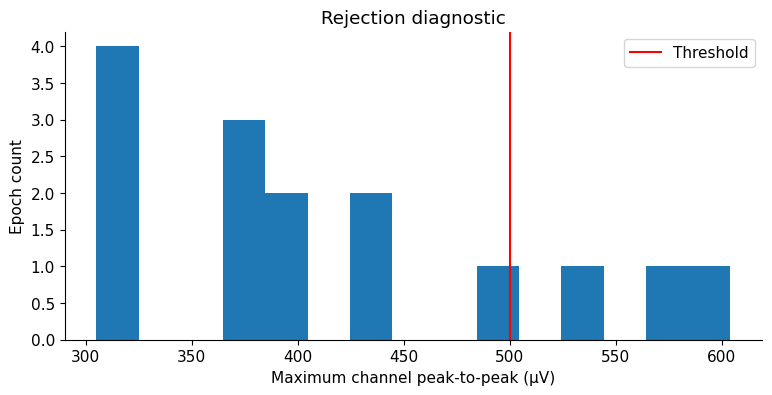

In [18]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Expose the numerical array; EEG values are in volts and the final axis is time.
ax.hist(np.ptp(base.get_data(), axis=-1).max(axis=1) * 1000000.0, bins=15)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.axvline(threshold * 1000000.0, color='red', label='Threshold')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Maximum channel peak-to-peak (µV)', ylabel='Epoch count', title='Rejection diagnostic')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Compare retained fractions by class, not just total count. If all epochs disappear, stop and investigate units, threshold and recording quality instead of proceeding with an empty classifier input.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Plot a retention curve by condition

**Try it:** Apply several thresholds to copies of the same candidate epochs. Show the retained fraction for each class.

**My reasoning / hand calculation:** _write here._

In [19]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Always start from base; do not repeatedly reject from an already reduced collection.

### Worked solution

Run the following calculation after attempting your own version.

/tmp/ipykernel_466822/2657249500.py:3: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  lab_kept=base.copy().drop_bad(reject={'eeg':threshold_uV*1e-6},verbose=False)
/tmp/ipykernel_466822/2657249500.py:3: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  lab_kept=base.copy().drop_bad(reject={'eeg':threshold_uV*1e-6},verbose=False)


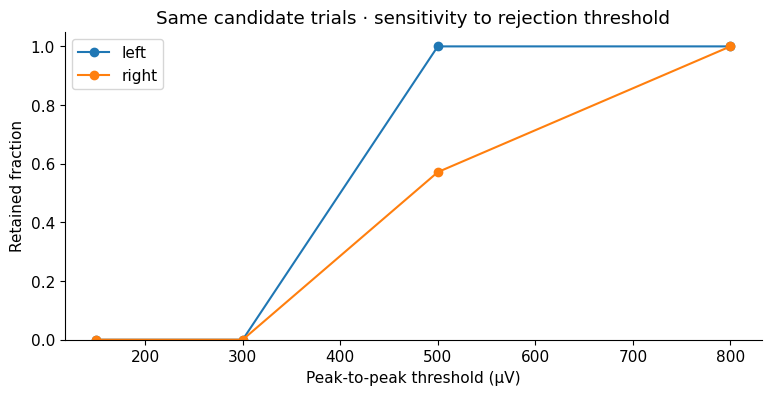

   threshold_uV condition  fraction
0           150      left  0.000000
1           150     right  0.000000
2           300      left  0.000000
3           300     right  0.000000
4           500      left  1.000000
5           500     right  0.571429
6           800      left  1.000000
7           800     right  1.000000


In [20]:
lab_rows=[]
for threshold_uV in [150,300,500,800]:
    lab_kept=base.copy().drop_bad(reject={'eeg':threshold_uV*1e-6},verbose=False)
    for name,event in base.event_id.items():
        lab_before=np.sum(base.events[:,2]==event)
        lab_after=np.sum(lab_kept.events[:,2]==event)
        lab_rows.append({'threshold_uV':threshold_uV,'condition':name,'fraction':lab_after/lab_before})
lab_table=pd.DataFrame(lab_rows)
fig,ax=plt.subplots(figsize=(9,4))
for name,table in lab_table.groupby('condition'):
    ax.plot(table.threshold_uV,table.fraction,'o-',label=name)
ax.set(ylim=(0,1.05),xlabel='Peak-to-peak threshold (µV)',ylabel='Retained fraction',title='Same candidate trials · sensitivity to rejection threshold')
ax.legend();plt.show();print(lab_table)

### Interpret and check

A larger threshold cannot remove more trials under the same criterion, so retention should be nondecreasing. Unequal class curves indicate a potential selection effect. Choose a threshold using recording quality and calibration evidence, not whichever final test score is largest.

## Practice 4 · Audit a dropped trial

**Try it:** Name two distinct reasons that an event may not become a retained epoch and explain why they should not be merged in a report.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Consider recording boundaries as well as signal amplitude.

### Worked solution

An epoch may extend beyond available samples, or it may violate an artifact/amplitude criterion. Boundary loss reflects acquisition and interval selection; amplitude rejection reflects a quality decision. The drop log and per-class counts should distinguish them so another analyst can reconstruct the effective sample.

## Verify a baseline numerically
Use this for understanding ERP baselines, not as a mandatory motor-imagery step.

Baseline subtraction is demonstrated separately from the main imagery pipeline. The numerical check verifies the selected baseline mean, illustrating an invariant that can catch an incorrect time mask or axis.

### Step 3.1 · trace the next operation

**1.** Subtract each trial/channel’s mean over the named reference interval.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [21]:
# Subtract each trial/channel’s mean over the named reference interval.
baseline_epochs = base.copy().apply_baseline((-0.5, 0))
# Store this intermediate result so the next operation can be traced and inspected.
mask = (baseline_epochs.times >= -0.5) & (baseline_epochs.times <= 0)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert np.allclose(baseline_epochs.get_data()[:, :, mask].mean(-1), 0, atol=1e-12)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Baseline mean is numerically zero.')

Baseline mean is numerically zero.


### Inspect and interpret

Explain why zero baseline mean does not imply zero post-event drift. Identify which values changed and which peak-to-peak ranges should remain unchanged.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 5 · Predict what baseline subtraction preserves

**Try it:** Does the peak-to-peak range change after subtracting the baseline mean? Explain algebraically.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Subtract the same constant from both maximum and minimum.

### Worked solution

No: max(x−b)−min(x−b)=max(x)−min(x). Baseline subtraction changes the offset, not the within-epoch range. It can still alter ERP amplitudes relative to zero and can introduce bias if baseline periods differ systematically by condition.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

Events connect acquisition samples to experimental meaning. Epoching chooses temporal support, baseline subtraction changes offsets, and rejection changes which trials survive. Preserve the original selection and report class-specific retention and drop reasons.

## If your result is different

If no epochs survive, inspect volts versus microvolts, thresholds and drop_log. If event codes are unexpected, verify the run-specific protocol before remapping labels.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE epochs](https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html) · [Epoch rejection](https://mne.tools/stable/auto_tutorials/preprocessing/20_rejecting_bad_data.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.